# Tier4 PECNet YahooQuery Research

Bu notebook bilinçli olarak sade tutuldu:

- Veri doğrudan `yahooquery` ile çekilir.
- Feature engineering notebook içinde yapılır.
- Feast, Kedro, Dagster ve MLflow kullanılmaz.
- Tier4 PECNet mantığı notebook içinde eğitilir: target-history ile ilk ağ, residual-error korelasyonuyla cascade feature seçimi, sonra error network ve final network.

## 1. Imports

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from yahooquery import Ticker

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
PECNETFRAMEWORK_PATH = PROJECT_ROOT / "pecnetframework"
if str(PECNETFRAMEWORK_PATH) not in sys.path:
    sys.path.insert(0, str(PECNETFRAMEWORK_PATH))

from pecnet.network import PecnetBuilder
from pecnet.preprocessing.DataPreprocessor import DataPreprocessor
from pecnet.utils import FeatureSelector, Utility

pd.options.display.max_columns = 120
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Config

In [2]:
SYMBOLS = ["TUPRS.IS"]
PERIOD = "3y"
INTERVAL = "1d"

FEATURE_COLUMNS = [
    "prev_open",
    "prev_high",
    "prev_low",
    "prev_volume",
    "calendar_gap_days",
    "month_sin_1",
    "month_cos_1",
    "month_sin_2",
    "month_cos_2",
    "day_sin_1",
    "day_cos_1",
    "day_sin_2",
    "day_cos_2",
    "day_of_year_sin_1",
    "day_of_year_cos_1",
    "day_of_year_sin_2",
    "day_of_year_cos_2",
]

PREPROCESS_PARAMS = {
    "sampling_periods": [1, 4, 8],
    "sampling_statistics": ["mean", 'std'],
    "sequence_size": 4,
    "error_sequence_size": 8,
    "wavelet_type": "haar",
    "test_ratio": 0.1,
    'scale_factor': 1.3,
    'normalization_type': None,
    'conjoincy': True,
}

HYPERPARAMS = {
    "seed": 42,
    "learning_rate": 0.001,
    "epoch_size": 500,
    "batch_size": 96,
    "hidden_units_sizes": [32, 64, 32, 16],
}

SELECTION_PARAMS = {
    "correlation_threshold": 0.08,
    "max_selected_features": 5,
}

## 3. YahooQuery Data Pull

In [3]:
def _datetime_column(frame: pd.DataFrame) -> str | None:
    for column in ["date", "datetime", "level_1", "index"]:
        if column not in frame.columns:
            continue
        converted = pd.to_datetime(frame[column], errors="coerce", utc=True)
        if converted.notna().mean() >= 0.8:
            return column
    return None


def normalize_yahooquery_history(raw: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if isinstance(raw, dict):
        raise RuntimeError(f"YahooQuery returned an error payload for {symbol}: {raw}")
    if raw is None or raw.empty:
        raise RuntimeError(f"YahooQuery returned no rows for {symbol}.")

    frame = raw.reset_index().copy()
    frame.columns = [str(column).lower() for column in frame.columns]

    date_column = _datetime_column(frame)
    if date_column is None:
        raise ValueError(f"Could not find a datetime column for {symbol}. Columns={list(frame.columns)}")
    if date_column != "date":
        frame = frame.rename(columns={date_column: "date"})

    if "symbol" not in frame.columns:
        frame["symbol"] = symbol
    else:
        frame["symbol"] = frame["symbol"].fillna(symbol).astype(str)

    required = ["symbol", "date", "open", "high", "low", "close", "volume"]
    missing = sorted(set(required).difference(frame.columns))
    if missing:
        raise ValueError(f"YahooQuery data for {symbol} is missing columns: {missing}. Columns={list(frame.columns)}")

    frame = frame[required].copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="coerce", utc=True).dt.tz_convert(None)
    for column in ["open", "high", "low", "close", "volume"]:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=required).sort_values(["symbol", "date"])
    return frame.reset_index(drop=True)


def fetch_yahooquery_prices(
    symbols: list[str],
    *,
    period: str,
    interval: str,
) -> pd.DataFrame:
    frames = []
    for symbol in symbols:
        print(f"Fetching {symbol}...")
        raw = Ticker(symbol, asynchronous=False).history(period=period, interval=interval)
        frames.append(normalize_yahooquery_history(raw, symbol))
    if not frames:
        raise RuntimeError("No symbols were requested.")
    return pd.concat(frames, ignore_index=True).sort_values(["symbol", "date"]).reset_index(drop=True)

In [4]:
prices = fetch_yahooquery_prices(SYMBOLS, period=PERIOD, interval=INTERVAL)
print(f"rows={len(prices):,} symbols={prices['symbol'].nunique()}")
display(prices.groupby("symbol").agg(rows=("date", "size"), start=("date", "min"), end=("date", "max")))
display(prices.tail())

Fetching TUPRS.IS...
rows=753 symbols=1


,rows,start,end
symbol,,,
TUPRS.IS,753,2023-07-17,2026-07-14


,symbol,date,open,high,low,close,volume
748,TUPRS.IS,2026-07-08,260.50,265.75,255.25,256.50,39550021.0
749,TUPRS.IS,2026-07-09,258.00,264.25,257.50,264.25,20337023.0
750,TUPRS.IS,2026-07-10,264.25,270.00,262.25,267.00,25522430.0
751,TUPRS.IS,2026-07-13,271.50,273.00,266.50,268.25,24414654.0
752,TUPRS.IS,2026-07-14,270.00,273.50,267.75,270.75,24519320.0


## 4. Feature Engineering

In [5]:
def fourier_terms(date: pd.Series, *, period: float, harmonics: tuple[int, ...], prefix: str) -> pd.DataFrame:
    values = date.astype(float)
    data = {}
    for harmonic in harmonics:
        angle = 2.0 * np.pi * harmonic * values / period
        data[f"{prefix}_sin_{harmonic}"] = np.sin(angle)
        data[f"{prefix}_cos_{harmonic}"] = np.cos(angle)
    return pd.DataFrame(data, index=date.index)

In [6]:
def fill_business_days_for_symbol(symbol_frame: pd.DataFrame) -> pd.DataFrame:
    print(f"Filling business days for {symbol_frame}...")
    symbol = str(symbol_frame.name)
    print(f"Filling business days for {symbol}...")
    symbol_frame = symbol_frame.sort_values("date").drop_duplicates("date", keep="last")
    grid = pd.DataFrame({"date": pd.bdate_range(symbol_frame["date"].min(), symbol_frame["date"].max())})
    filled = grid.merge(symbol_frame, on="date", how="left")
    filled["symbol"] = symbol
    filled["synthetic_row"] = filled["close"].isna()

    price_columns = ["open", "high", "low", "close", "volume"]
    filled[price_columns] = filled[price_columns].ffill().bfill()

    actual_segment = (~filled["synthetic_row"]).astype(int).cumsum()
    synthetic_run = filled.groupby(actual_segment).cumcount()
    previous_run = synthetic_run.shift(1).fillna(0).astype(int)
    filled["calendar_gap_days"] = np.where(
        filled["synthetic_row"],
        synthetic_run,
        np.where(previous_run > 0, previous_run, 0),
    ).astype(float)
    return filled

In [7]:
prices_copy = prices.copy()
gruplanmis = prices_copy.groupby("symbol", group_keys=False)

for isim, grup in gruplanmis:
    print(f"--- Grup: {isim} ---")
    display(grup) # Konsolda çalışıyorsan 'print(grup)' kullanabilirsin

--- Grup: TUPRS.IS ---


,symbol,date,open,high,low,close,volume
0,TUPRS.IS,2023-07-17,89.500000,91.550003,89.400002,90.099998,32762485.0
1,TUPRS.IS,2023-07-18,90.099998,90.550003,86.349998,86.500000,29876602.0
2,TUPRS.IS,2023-07-19,86.500000,89.449997,85.000000,89.449997,23650124.0
3,TUPRS.IS,2023-07-20,90.000000,91.000000,88.599998,91.000000,41038751.0
4,TUPRS.IS,2023-07-21,91.500000,93.199997,90.250000,91.400002,51285128.0
...,...,...,...,...,...,...,...
748,TUPRS.IS,2026-07-08,260.500000,265.750000,255.250000,256.500000,39550021.0
749,TUPRS.IS,2026-07-09,258.000000,264.250000,257.500000,264.250000,20337023.0
750,TUPRS.IS,2026-07-10,264.250000,270.000000,262.250000,267.000000,25522430.0
751,TUPRS.IS,2026-07-13,271.500000,273.000000,266.500000,268.250000,24414654.0


In [8]:
def build_tier4_features(prices: pd.DataFrame) -> pd.DataFrame:
    filled = (
        prices.groupby("symbol", group_keys=False)
        .apply(fill_business_days_for_symbol)
        .reset_index(drop=True)
        .sort_values(["symbol", "date"])
    )
    print(f"rows={len(filled):,} symbols={filled['symbol'].nunique()}")
    display(filled)
    for column in ["open", "high", "low", "volume"]:
        filled[f"prev_{column}"] = filled.groupby("symbol")[column].shift(1)

    month_terms = fourier_terms(filled["date"].dt.month, period=12.0, harmonics=(1, 2), prefix="month")
    day_terms = fourier_terms(filled["date"].dt.day, period=31.0, harmonics=(1, 2), prefix="day")
    doy_terms = fourier_terms(filled["date"].dt.dayofyear, period=366.0, harmonics=(1, 2), prefix="day_of_year")
    enriched = pd.concat([filled, month_terms, day_terms, doy_terms], axis=1)
    print(f"rows={len(enriched):,} symbols={enriched['symbol'].nunique()}")
    model_frame = enriched.rename(columns={"symbol": "unique_id", "date": "ds", "close": "y"})
    model_frame = model_frame[["unique_id", "ds", "y", *FEATURE_COLUMNS]].copy()
    model_frame = model_frame.dropna(subset=["unique_id", "ds", "y", *FEATURE_COLUMNS])
    return model_frame.sort_values(["unique_id", "ds"]).reset_index(drop=True)

In [9]:
model_frame = build_tier4_features(prices)
print(f"model_rows={len(model_frame):,}")
display(model_frame.groupby("unique_id").agg(rows=("ds", "size"), start=("ds", "min"), end=("ds", "max")))
display(model_frame.tail())

Filling business days for           date        open        high         low       close      volume
0   2023-07-17   89.500000   91.550003   89.400002   90.099998  32762485.0
1   2023-07-18   90.099998   90.550003   86.349998   86.500000  29876602.0
2   2023-07-19   86.500000   89.449997   85.000000   89.449997  23650124.0
3   2023-07-20   90.000000   91.000000   88.599998   91.000000  41038751.0
4   2023-07-21   91.500000   93.199997   90.250000   91.400002  51285128.0
..         ...         ...         ...         ...         ...         ...
748 2026-07-08  260.500000  265.750000  255.250000  256.500000  39550021.0
749 2026-07-09  258.000000  264.250000  257.500000  264.250000  20337023.0
750 2026-07-10  264.250000  270.000000  262.250000  267.000000  25522430.0
751 2026-07-13  271.500000  273.000000  266.500000  268.250000  24414654.0
752 2026-07-14  270.000000  273.500000  267.750000  270.750000  24519320.0

[753 rows x 6 columns]...
Filling business days for TUPRS.IS...
rows=782 

,date,open,high,low,close,volume,symbol,synthetic_row,calendar_gap_days
0,2023-07-17,89.500000,91.550003,89.400002,90.099998,32762485.0,TUPRS.IS,False,0.0
1,2023-07-18,90.099998,90.550003,86.349998,86.500000,29876602.0,TUPRS.IS,False,0.0
2,2023-07-19,86.500000,89.449997,85.000000,89.449997,23650124.0,TUPRS.IS,False,0.0
3,2023-07-20,90.000000,91.000000,88.599998,91.000000,41038751.0,TUPRS.IS,False,0.0
4,2023-07-21,91.500000,93.199997,90.250000,91.400002,51285128.0,TUPRS.IS,False,0.0
...,...,...,...,...,...,...,...,...,...
777,2026-07-08,260.500000,265.750000,255.250000,256.500000,39550021.0,TUPRS.IS,False,0.0
778,2026-07-09,258.000000,264.250000,257.500000,264.250000,20337023.0,TUPRS.IS,False,0.0
779,2026-07-10,264.250000,270.000000,262.250000,267.000000,25522430.0,TUPRS.IS,False,0.0
780,2026-07-13,271.500000,273.000000,266.500000,268.250000,24414654.0,TUPRS.IS,False,0.0


rows=782 symbols=1
model_rows=781


,rows,start,end
unique_id,,,
TUPRS.IS,781,2023-07-18,2026-07-14


,unique_id,ds,y,prev_open,prev_high,prev_low,prev_volume,calendar_gap_days,month_sin_1,month_cos_1,month_sin_2,month_cos_2,day_sin_1,day_cos_1,day_sin_2,day_cos_2,day_of_year_sin_1,day_of_year_cos_1,day_of_year_sin_2,day_of_year_cos_2
776,TUPRS.IS,2026-07-08,256.50,247.800003,259.25,247.800003,27252807.0,0.0,-0.5,-0.866025,0.866025,0.5,0.998717,-0.050649,-0.101168,-0.994869,-0.102821,-0.994700,0.204552,0.978856
777,TUPRS.IS,2026-07-09,264.25,260.500000,265.75,255.250000,39550021.0,0.0,-0.5,-0.866025,0.866025,0.5,0.968077,-0.250653,-0.485302,-0.874347,-0.119881,-0.992788,0.238033,0.971257
778,TUPRS.IS,2026-07-10,267.00,258.000000,264.25,257.500000,20337023.0,0.0,-0.5,-0.866025,0.866025,0.5,0.897805,-0.440394,-0.790776,-0.612106,-0.136906,-0.990584,0.271234,0.962513
779,TUPRS.IS,2026-07-13,268.25,264.250000,270.00,262.250000,25522430.0,0.0,-0.5,-0.866025,0.866025,0.5,0.485302,-0.874347,-0.848644,0.528964,-0.187719,-0.982223,0.368763,0.929523
780,TUPRS.IS,2026-07-14,270.75,271.500000,273.00,266.500000,24414654.0,0.0,-0.5,-0.866025,0.866025,0.5,0.299363,-0.954139,-0.571268,0.820763,-0.204552,-0.978856,0.400454,0.916317


## 5. PECNet Tier4 Helpers

In [10]:
def preprocess_ticker(
    *,
    ticker_df: pd.DataFrame,
    ticker: str,
    feature_columns: list[str],
    preprocess_params: dict[str, Any],
) -> dict[str, Any]:
    dp = DataPreprocessor()
    dp.reset()
    ticker_df = ticker_df.sort_values("ds").copy()
    params = {**preprocess_params}
    test_ratio = float(params.get("test_ratio", 0.1))
    if not 0 < test_ratio < 1:
        raise ValueError(f"PECNet test_ratio must be between 0 and 1, got {test_ratio}.")
    params["test_ratio"] = test_ratio

    target_series = ticker_df["y"].to_numpy(dtype=float)
    X_train_target, X_test_target, y_train, y_test = dp.preprocess(data=target_series, **params)

    feature_X_trains = []
    feature_X_tests = []
    available_features = [column for column in feature_columns if column in ticker_df.columns]
    for column in available_features:
        X_train_feature, X_test_feature, _, _ = dp.preprocess(
            data=ticker_df[column].to_numpy(dtype=float),
            **params,
        )
        feature_X_trains.append(X_train_feature)
        feature_X_tests.append(X_test_feature)

    return {
        "ticker": ticker,
        "dates": ticker_df["ds"].reset_index(drop=True),
        "X_train_target": X_train_target,
        "X_test_target": X_test_target,
        "y_train": y_train,
        "y_test": y_test,
        "feature_X_trains": feature_X_trains,
        "feature_X_tests": feature_X_tests,
        "feature_names": available_features,
        "preprocess_params": params,
    }


In [11]:
def candidate_variable_inputs(ticker_data: dict[str, Any]) -> tuple[list[str], list[np.ndarray], list[np.ndarray]]:
    return (
        ["target_history", *ticker_data["feature_names"]],
        [ticker_data["X_train_target"], *ticker_data["feature_X_trains"]],
        [ticker_data["X_test_target"], *ticker_data["feature_X_tests"]],
    )


def selection_row(
    *,
    ticker: str,
    order: int,
    feature_index: int,
    feature_name: str,
    correlation: float | None,
    reference_name: str,
    threshold: float | None,
) -> dict[str, Any]:
    return {
        "ticker": ticker,
        "tier": "tier4",
        "strategy": "thesis_wavelet_error_compensated_fusion",
        "selection_order": order,
        "feature_index": feature_index,
        "feature_name": feature_name,
        "reference_name": reference_name,
        "correlation": correlation,
        "abs_correlation": abs(correlation) if correlation is not None else None,
        "threshold": threshold,
    }

In [12]:
def build_tier4_pecnet_variables(
    *,
    builder,
    ticker_data: dict[str, Any],
    selection_params: dict[str, Any],
) -> tuple[Any, list[np.ndarray], pd.DataFrame]:
    candidate_names, candidate_X_train, candidate_X_test = candidate_variable_inputs(ticker_data)
    print(f"Building tier4 pecnet variables for {ticker_data['ticker']} with {len(candidate_names)} candidates...")
    builder.add_variable_network(ticker_data["X_train_target"], ticker_data["y_train"])
    rows = [
        selection_row(
            ticker=ticker_data["ticker"],
            order=1,
            feature_index=0,
            feature_name="target_history",
            correlation=None,
            reference_name="target_y",
            threshold=None,
        )
    ]

    external_X_train = candidate_X_train[1:]
    external_names = candidate_names[1:]
    if not external_X_train:
        return builder, [candidate_X_test[0]], pd.DataFrame(rows)

    threshold = float(selection_params.get("correlation_threshold", 0.08))
    max_selected_features = selection_params.get("max_selected_features")
    max_selected_features = int(max_selected_features) if max_selected_features is not None else None
    selector = FeatureSelector(threshold=threshold)
    reference = builder.pecnet.get_target_values_for_current_variable_network()

    while True:
        if max_selected_features is not None and len(rows) >= max_selected_features:
            break
        selected_external_index = selector.select_next(
            external_X_train,
            reference,
            force_include_best_if_first=False,
        )
        if selected_external_index is None:
            break

        builder.add_variable_network(external_X_train[selected_external_index], reference)
        correlation = selector.get_last_corr_score()
        rows.append(
            selection_row(
                ticker=ticker_data["ticker"],
                order=len(rows) + 1,
                feature_index=selected_external_index + 1,
                feature_name=external_names[selected_external_index],
                correlation=float(correlation) if correlation is not None else None,
                reference_name="residual_error",
                threshold=threshold,
            )
        )
        reference = builder.pecnet.get_target_values_for_current_variable_network()

    selected_X_test = [candidate_X_test[int(row["feature_index"])] for row in rows]
    return builder, selected_X_test, pd.DataFrame(rows)

In [13]:
def regression_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(actual, predicted)),
        "rmse": float(np.sqrt(mean_squared_error(actual, predicted))),
        "mape": float(mean_absolute_percentage_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)) if len(actual) > 1 else np.nan,
    }


def directional_metrics(joined: pd.DataFrame, full_df: pd.DataFrame) -> dict[str, float]:
    previous_close = (
        full_df[["unique_id", "ds", "y"]]
        .sort_values(["unique_id", "ds"])
        .assign(previous_y=lambda frame: frame.groupby("unique_id")["y"].shift(1))
    )
    eval_frame = joined.merge(previous_close[["unique_id", "ds", "previous_y"]], on=["unique_id", "ds"], how="left")
    actual_up = eval_frame["y"] > eval_frame["previous_y"]
    predicted_up = eval_frame["PECNet"] > eval_frame["previous_y"]
    valid = eval_frame["previous_y"].notna()
    if not valid.any():
        return {"long_accuracy": np.nan, "long_precision": np.nan, "long_recall": np.nan, "long_signal_rate": np.nan}
    tp = int((predicted_up & actual_up & valid).sum())
    fp = int((predicted_up & ~actual_up & valid).sum())
    fn = int((~predicted_up & actual_up & valid).sum())
    return {
        "long_accuracy": float((predicted_up[valid] == actual_up[valid]).mean()),
        "long_precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "long_recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "long_signal_rate": float(predicted_up[valid].mean()),
    }


## 6. Train Tier4 PECNet

In [14]:
def train_one_ticker_tier4(
    *,
    ticker: str,
    full_df: pd.DataFrame,
) -> tuple[Any, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    Utility.set_seed(HYPERPARAMS["seed"])
    Utility.set_hyperparameters(
        learning_rate=HYPERPARAMS["learning_rate"],
        epoch_size=HYPERPARAMS["epoch_size"],
        batch_size=HYPERPARAMS["batch_size"],
        hidden_units_sizes=HYPERPARAMS["hidden_units_sizes"],
    )

    full_df = full_df.sort_values("ds").copy()
    ticker_data = preprocess_ticker(
        ticker_df=full_df,
        ticker=ticker,
        feature_columns=FEATURE_COLUMNS,
        preprocess_params=PREPROCESS_PARAMS,
    )
    builder, selected_X_test, selection = build_tier4_pecnet_variables(
        builder=PecnetBuilder(),
        ticker_data=ticker_data,
        selection_params=SELECTION_PARAMS,
    )
    display(selection)
    pecnet = builder.add_error_network().add_final_network().build()
    predictions = pecnet.predict(*selected_X_test, test_target=ticker_data["y_test"])
    predictions = predictions.detach().cpu().numpy().reshape(-1) if hasattr(predictions, "detach") else np.asarray(predictions).reshape(-1)

    prediction_dates = full_df[["unique_id", "ds", "y"]].tail(len(predictions)).reset_index(drop=True)
    joined = prediction_dates.copy()
    joined["PECNet"] = predictions[-len(joined):]

    metrics = {
        "ticker": ticker,
        "pecnet_test_ratio": ticker_data["preprocess_params"]["test_ratio"],
        "pecnet_test_rows": len(joined),
        **regression_metrics(joined["y"].to_numpy(), joined["PECNet"].to_numpy()),
        **directional_metrics(joined, full_df),
        "selected_features": ",".join(selection["feature_name"].tolist()),
    }
    return pecnet, joined, pd.DataFrame([metrics]), selection


In [15]:
models = {}
prediction_frames = []
metric_frames = []
selection_frames = []

for ticker, full_symbol_df in model_frame.groupby("unique_id", observed=True):
    print(f"Training tier4 PECNet for {ticker}...")
    model, joined, metrics, selection = train_one_ticker_tier4(
        ticker=str(ticker),
        full_df=full_symbol_df.copy(),
    )
    models[str(ticker)] = model
    prediction_frames.append(joined)
    metric_frames.append(metrics)
    selection_frames.append(selection)

predictions = pd.concat(prediction_frames, ignore_index=True)
metrics = pd.concat(metric_frames, ignore_index=True)
feature_selection = pd.concat(selection_frames, ignore_index=True)

display(metrics)
display(feature_selection)


Training tier4 PECNet for TUPRS.IS...
DataPreprocessor Initialized
DataPreprocessor Reset
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Initial data size: 781 ------
Building tier4 pecnet variables for TUPRS.IS with 18 candidates...
Mode:  train  Cascaded Neural Network for frequency 0 and statistic 0 is working...

[Variable_0_Network_0] Epoch 1/500 | Loss: 0.016100
[Variable_0_Network_0] Epoch 11/500 | Loss: 0.000514
[Variable_0_Network_0] Epoch 21/500 | Loss: 0.000485
[Variable_0_Network_0] Epoch 31/500 | Loss: 0.000471
[Variab

KeyboardInterrupt: 

## 7. Visual Checks

In [ ]:
def plot_predictions(predictions: pd.DataFrame) -> None:
    symbols = predictions["unique_id"].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(symbols), 1, figsize=(14, 4 * len(symbols)), sharex=False)
    if len(symbols) == 1:
        axes = [axes]
    for axis, symbol in zip(axes, symbols, strict=False):
        frame = predictions[predictions["unique_id"] == symbol].sort_values("ds")
        axis.plot(frame["ds"], frame["y"], label="actual", linewidth=2)
        axis.plot(frame["ds"], frame["PECNet"], label="PECNet", linewidth=2)
        axis.set_title(f"{symbol} Tier4 PECNet: Actual vs Prediction")
        axis.legend()
    plt.tight_layout()
    plt.show()


def plot_feature_selection(feature_selection: pd.DataFrame) -> None:
    plot_df = feature_selection.dropna(subset=["abs_correlation"]).copy()
    if plot_df.empty:
        print("No correlation-based feature selection rows to plot.")
        return
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = plot_df["ticker"] + " #" + plot_df["selection_order"].astype(str) + " " + plot_df["feature_name"]
    ax.bar(labels, plot_df["abs_correlation"])
    ax.set_title("Tier4 Residual-Correlation Feature Selection")
    ax.set_ylabel("abs(correlation)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

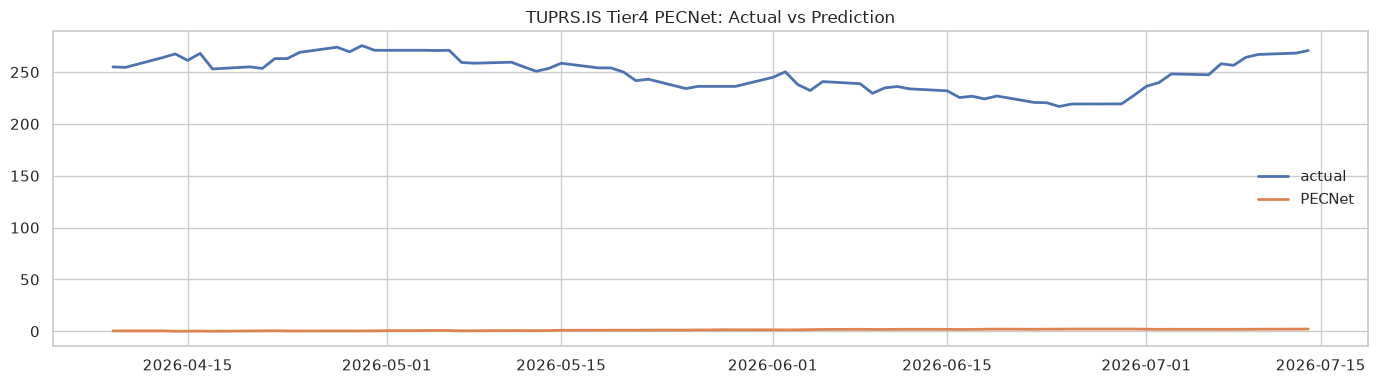

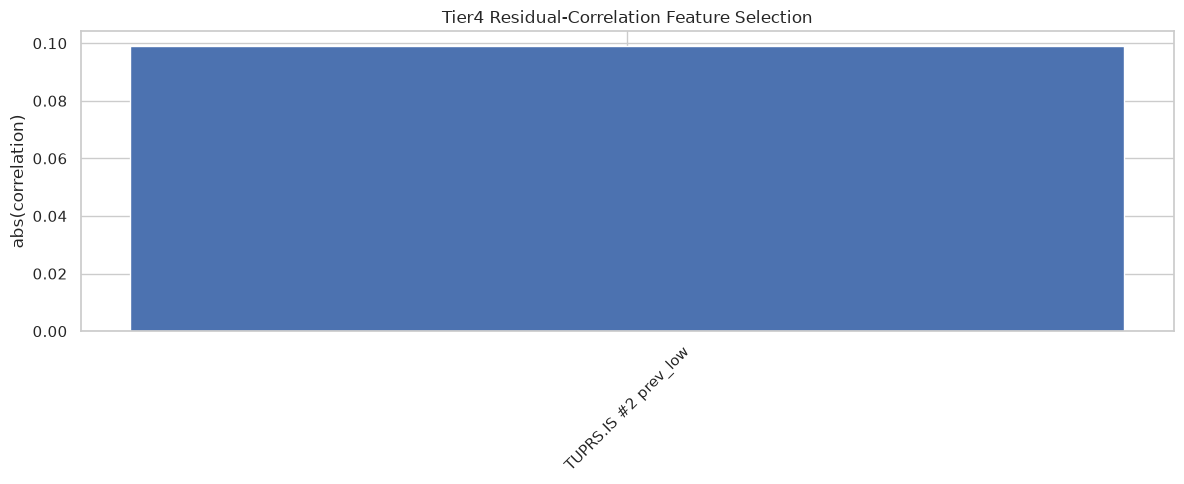

In [ ]:
plot_predictions(predictions)
plot_feature_selection(feature_selection)

## 7.1 PECNet Utility Plot

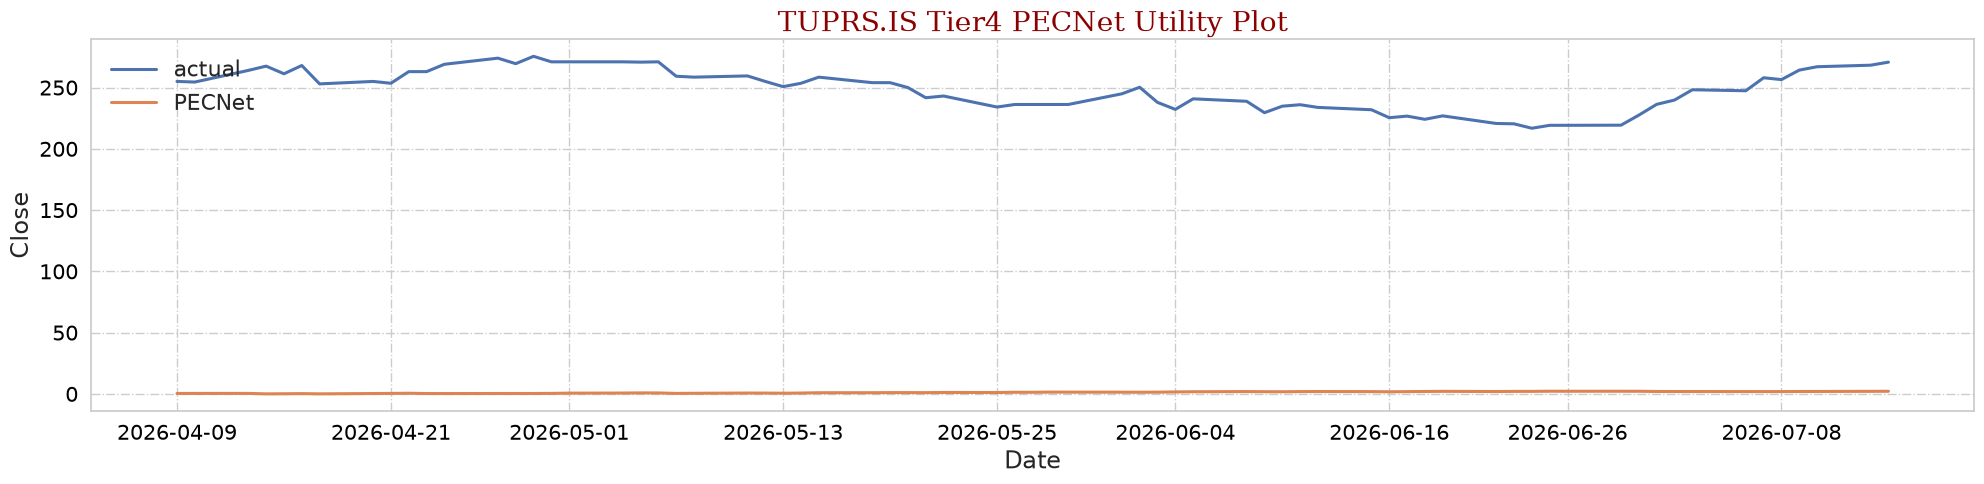

In [ ]:
def plot_predictions_with_pecnet_utility(predictions: pd.DataFrame) -> None:
    for symbol, frame in predictions.groupby("unique_id", observed=True):
        frame = frame.sort_values("ds")
        Utility.plot(
            frame["ds"].to_numpy(),
            frame["y"].to_numpy(),
            frame["PECNet"].to_numpy(),
            title=f"{symbol} Tier4 PECNet Utility Plot",
            xlabel="Date",
            ylabel="Close",
            tick_size=8,
            labels=["actual", "PECNet"],
        )


plot_predictions_with_pecnet_utility(predictions)